# 01 — Validación de instancias

Este cuaderno valida el **conjunto de instancias** del generador de puntos de
recogida de residuos (una por radio) apoyándose por completo en la librería
`analisis`: **no contiene lógica inline**, solo narrativa + llamadas a
`estilo`, `rutas`, `metricas`, `geo`, `mapas` y `comparativas`.

- **Sección A — Grafo**: integridad topológica de la red de calles (`geo.validar_grafo`).
- **Sección B — Demanda y outliers**: distribución de `h_i`, outliers IQR y
  densidad calibrada por convex-hull (`metricas.outliers_demanda_iqr`, `geo.densidad_convexhull`).
- **Sección C — Distancias y cobertura**: distancias edificio↔candidato y
  cobertura por tipo de residuo (`metricas.resumen_distancias`, `cobertura_por_tipo`,
  `candidatos_reales_vs_artificiales`).
- **Tabla comparativa** final (`comparativas.tabla_instancias`).

Los **cómputos** se hacen para los radios `[500, 1000, 1500]`; los **mapas**, solo
para `[500, 1500]` (dos listas distintas a propósito).

In [ ]:
import sys
sys.path.insert(0, "../src/python")   # mínimo para importar 'analisis' (patrón de 02/03)

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from instancia import load_instance
from analisis import estilo, rutas, metricas, geo, mapas, comparativas

# Radios de CÓMPUTO/tabla y de MAPAS: listas distintas a propósito (no se pinta el 1000 m).
RADIOS = [500, 1000, 1500]
RADIOS_MAPA = [500, 1500]

# Instancias cargadas una sola vez; rutas ancladas a la raíz del repo vía rutas.*.
INSTANCIAS = {r: load_instance(str(rutas.ruta_instancia(r))) for r in RADIOS}
print(f"Instancias cargadas: {sorted(INSTANCIAS)}   |   radios de mapa: {RADIOS_MAPA}")
print(f"Tipos de residuo (estilo.TIPOS_RESIDUO): {estilo.TIPOS_RESIDUO}")

Instancias cargadas: [500, 1000, 1500]   |   radios de mapa: [500, 1500]
Tipos de residuo (estilo.TIPOS_RESIDUO): {0: 'Orgánica', 1: 'Resto', 2: 'Reciclable', 3: 'Peligrosos'}


## Sección A — Integridad del grafo

Antes de validar edificios o distancias comprobamos que la **red de calles**
descargada de OSMnx es sólida: tamaño, **conectividad** (un grafo fragmentado
daría distancias ∞ entre zonas), **aristas anormalmente largas** (>500 m, señal
de descarga sospechosa) y **nodos aislados**. Todo se delega en
`geo.validar_grafo(r)`, que carga el graphml del tamaño y devuelve las métricas
topológicas. El mapa de la red se dibuja solo para 500 y 1500 m.

In [ ]:
# Salud topológica de cada tamaño (una fila por radio).
df_grafo = pd.DataFrame({r: geo.validar_grafo(r) for r in RADIOS}).T
df_grafo.index.name = "Radio (m)"
display(df_grafo)

,n_nodos,n_aristas,n_componentes_conexas,es_conexo,n_nodos_artificiales,n_aristas_largas,n_nodos_aislados
Radio (m),,,,,,,
500,274,740,1,True,0,2,0
1000,913,2547,1,True,0,2,0
1500,1969,5489,1,True,0,26,0


Figura guardada: output/figuras/01_red_500m.png


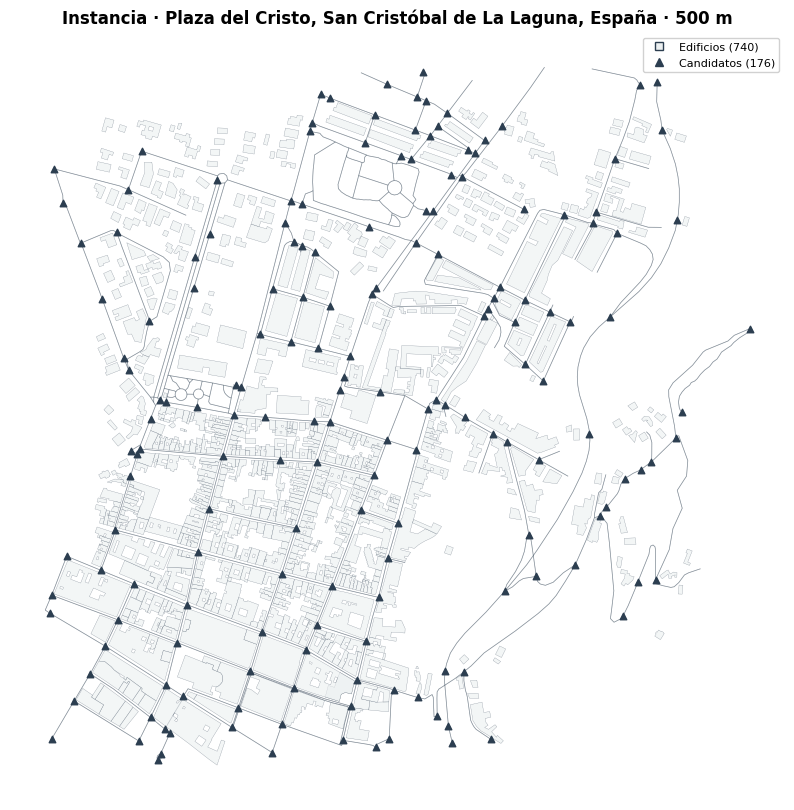

Figura guardada: output/figuras/01_red_1500m.png


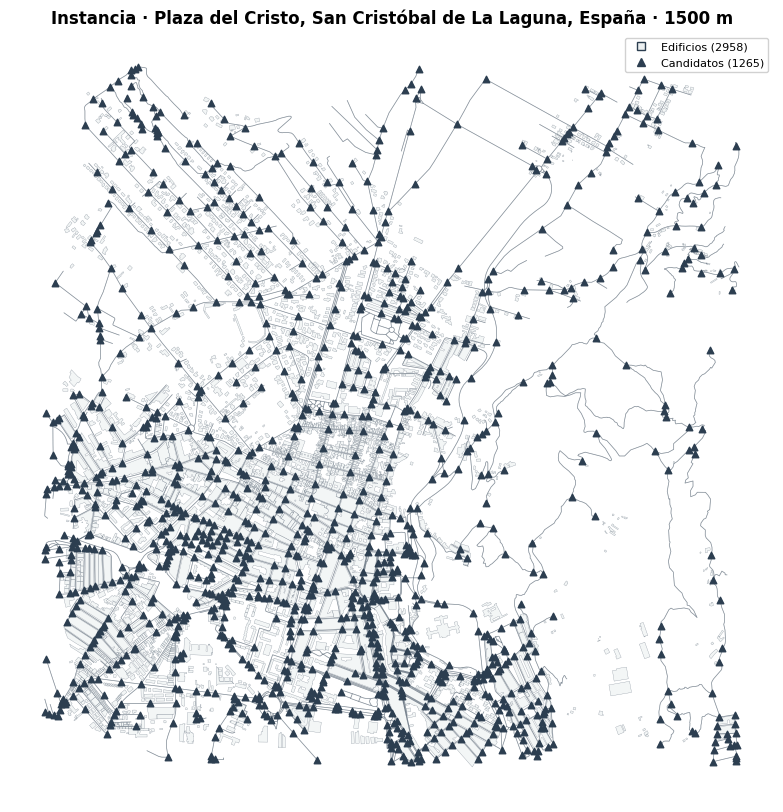

In [ ]:
# Mapa de la red + edificios/candidatos SOLO para 500 y 1500 m (NO 1000).
for r in RADIOS_MAPA:
    ax = mapas.mapa_instancia(INSTANCIAS[r], r)
    ruta = rutas.ruta_figura(f"01_red_{r}m")
    ruta.parent.mkdir(parents=True, exist_ok=True)
    ax.figure.savefig(ruta, dpi=120, bbox_inches="tight")
    print(f"Figura guardada: {ruta.relative_to(rutas.raiz_repo())}")
    plt.show()

## Sección B — Demanda y detección de outliers

La **demanda** es el corazón del problema: cada edificio genera residuos según su
población estimada `h_i`. Validamos su distribución y detectamos **outliers** por
la regla del rango intercuartílico (`metricas.outliers_demanda_iqr`: edificios con
`h_i > Q3 + 1.5·IQR`, típicamente parkings/colegios/naves con demanda no
doméstica). Como control de **calibración**, `geo.densidad_convexhull` mide el área
del convex-hull de los edificios (reproyectada a UTM para obtener km² reales) y la
densidad resultante, que debe rondar la densidad oficial del núcleo
(INE ≈ 4471 hab/km²) usada para anclar la población. El mapa de demanda se dibuja
solo para 500 y 1500 m.

In [ ]:
for r in RADIOS:
    inst = INSTANCIAS[r]
    out = metricas.outliers_demanda_iqr(inst)
    dens = geo.densidad_convexhull(inst)
    print(f"── {r} m ──")
    print(f"  Edificios: {inst.n_buildings:,}   |   población total (Σ h_i): "
          f"{inst.total_population:,.0f} hab")
    print(f"  Outliers IQR: {out['n_outliers']} edificios (umbral h_i > {out['umbral']:.1f}); "
          f"concentran {out['pct_demanda_outliers']:.1%} de la demanda")
    print(f"  Convex-hull: área {dens['area_km2']:.4f} km²  →  "
          f"densidad {dens['densidad_hab_km2']:,.0f} hab/km²")

── 500 m ──
  Edificios: 740   |   población total (Σ h_i): 4,472 hab
  Outliers IQR: 90 edificios (umbral h_i > 10.5); concentran 56.5% de la demanda
  Convex-hull: área 0.9908 km²  →  densidad 4,513 hab/km²
── 1000 m ──
  Edificios: 1,627   |   población total (Σ h_i): 16,584 hab
  Outliers IQR: 225 edificios (umbral h_i > 14.6); concentran 66.2% de la demanda
  Convex-hull: área 3.2818 km²  →  densidad 5,053 hab/km²


── 1500 m ──
  Edificios: 2,958   |   población total (Σ h_i): 39,802 hab
  Outliers IQR: 418 edificios (umbral h_i > 20.2); concentran 66.6% de la demanda
  Convex-hull: área 8.9518 km²  →  densidad 4,446 hab/km²


Figura guardada: output/figuras/01_demanda_500m.png


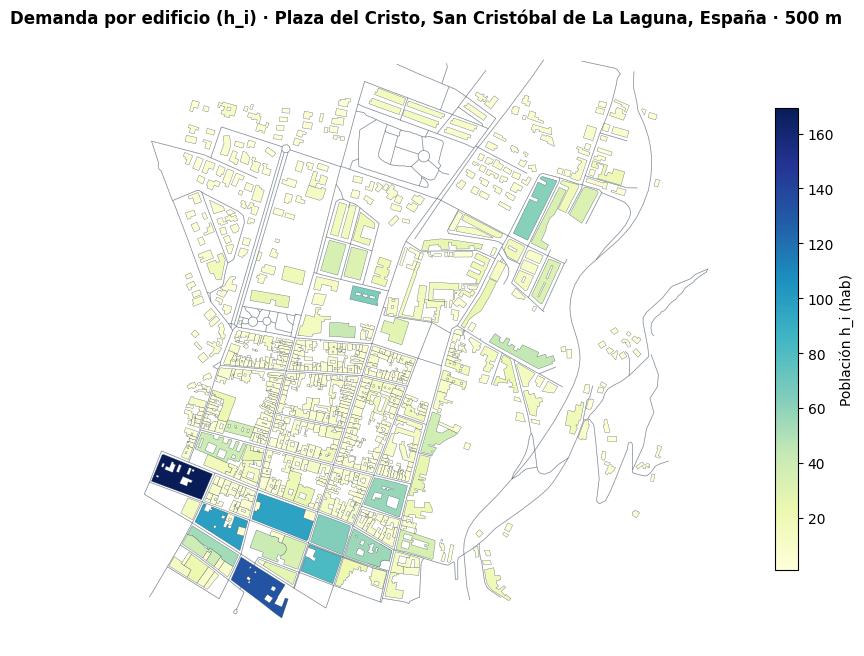

Figura guardada: output/figuras/01_demanda_1500m.png


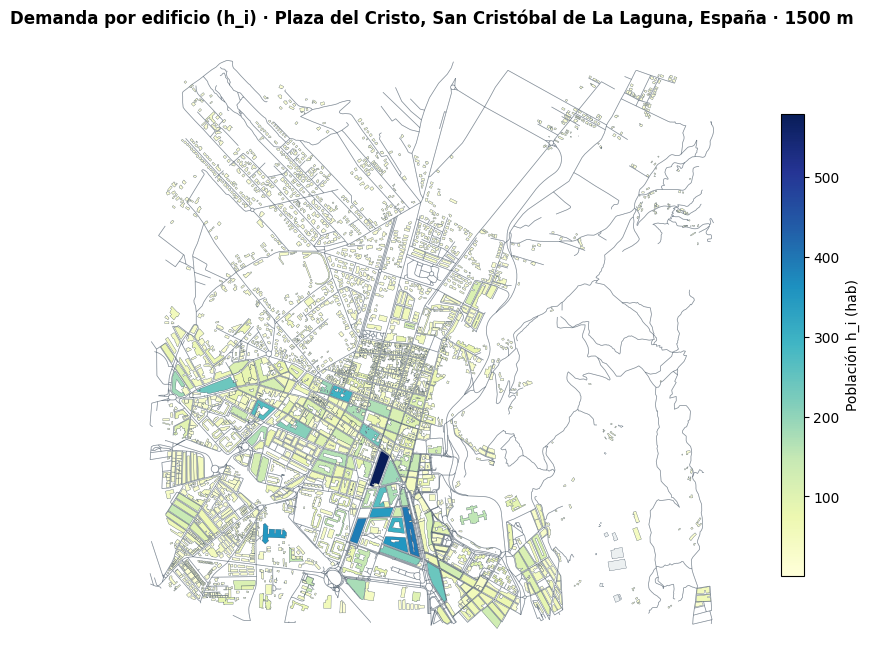

In [ ]:
# Mapa de demanda por edificio (h_i) SOLO para 500 y 1500 m (NO 1000).
for r in RADIOS_MAPA:
    ax = mapas.mapa_demanda(INSTANCIAS[r], r)
    ruta = rutas.ruta_figura(f"01_demanda_{r}m")
    ruta.parent.mkdir(parents=True, exist_ok=True)
    ax.figure.savefig(ruta, dpi=120, bbox_inches="tight")
    print(f"Figura guardada: {ruta.relative_to(rutas.raiz_repo())}")
    plt.show()

## Sección C — Distancias y cobertura

Las **distancias** edificio↔candidato son la base de las restricciones de
cobertura: un candidato "cubre" un edificio para un tipo `k` si su distancia es
≤ `coverage_radius[k]`. Validamos con `metricas.resumen_distancias` (sin ceros
espurios, acotadas por el cutoff de Dijkstra), `metricas.cobertura_por_tipo`
(candidatos accesibles por edificio y edificios sin cubrir, **por tipo**) y
`metricas.candidatos_reales_vs_artificiales`. Los radios de cobertura se **leen de
`inst.params.coverage_radius`** (no se fijan en el texto) y los tipos se etiquetan
con la taxonomía canónica `estilo.TIPOS_RESIDUO`.

In [ ]:
for r in RADIOS:
    inst = INSTANCIAS[r]
    dist = metricas.resumen_distancias(inst)
    cand = metricas.candidatos_reales_vs_artificiales(inst)
    cob = metricas.cobertura_por_tipo(inst)
    print(f"── {r} m ──")
    print(f"  Distancias: n={dist['n']:,}  media={dist['media']:.1f} m  máx={dist['max']:.1f} m "
          f"(cutoff Dijkstra {inst.dijkstra_radius_m} m; ceros={dist['n_cero']}, "
          f"<5 m={dist['n_sub5']}, >cutoff={dist['n_sobre_cutoff']})")
    print(f"  Candidatos: {cand['total']} (reales {cand['reales']} / artificiales {cand['artificiales']})")
    print(f"  Cobertura por tipo (radio real leído de inst.params.coverage_radius):")
    for k in inst.K:
        pt = cob["por_tipo"][k]
        print(f"    {estilo.nombre_tipo(k):<11} r={inst.params.coverage_radius[k]:>5.0f} m   "
              f"acc_media={pt['acc_media']:>5.1f}   sin_cobertura={pt['edificios_sin_cobertura']}")
    print(f"  → edificios sin cobertura en ALGÚN tipo: {cob['sin_cobertura_algun_tipo']}")

── 500 m ──
  Distancias: n=7,872  media=148.7 m  máx=225.0 m (cutoff Dijkstra 225 m; ceros=0, <5 m=0, >cutoff=0)
  Candidatos: 176 (reales 163 / artificiales 13)
  Cobertura por tipo (radio real leído de inst.params.coverage_radius):
    Orgánica    r=  125 m   acc_media=  3.4   sin_cobertura=0
    Resto       r=  125 m   acc_media=  3.4   sin_cobertura=0
    Reciclable  r=  175 m   acc_media=  6.4   sin_cobertura=0
    Peligrosos  r=  225 m   acc_media= 10.6   sin_cobertura=0
  → edificios sin cobertura en ALGÚN tipo: 0
── 1000 m ──
  Distancias: n=19,485  media=149.4 m  máx=225.0 m (cutoff Dijkstra 225 m; ceros=0, <5 m=0, >cutoff=0)
  Candidatos: 597 (reales 551 / artificiales 46)
  Cobertura por tipo (radio real leído de inst.params.coverage_radius):
    Orgánica    r=  125 m   acc_media=  3.8   sin_cobertura=0
    Resto       r=  125 m   acc_media=  3.8   sin_cobertura=0
    Reciclable  r=  175 m   acc_media=  7.2   sin_cobertura=0
    Peligrosos  r=  225 m   acc_media= 12.0   sin

## Tabla comparativa de instancias

Reúne las métricas clave de cada radio en una sola tabla. El cuaderno hace de
orquestador: llama a `metricas.*` y `geo.*` para cada instancia, arma un dict-fila
y se lo pasa a `comparativas.tabla_instancias`, que solo **formatea** (geo-free).
Sirve para verificar de un vistazo la **coherencia**: densidad ≈ 4471 hab/km²,
`sin_cobertura_algun_tipo` = 0 en todas, y edificios/candidatos/conexiones
crecientes con el radio.

In [ ]:
filas = []
for r in RADIOS:
    inst = INSTANCIAS[r]
    filas.append({
        "tam": r,
        "n_buildings": inst.n_buildings,
        "n_candidates": inst.n_candidates,
        "total_population": inst.total_population,
        "cobertura": metricas.cobertura_por_tipo(inst),
        "outliers": metricas.outliers_demanda_iqr(inst),
        "candidatos": metricas.candidatos_reales_vs_artificiales(inst),
        "distancias": metricas.resumen_distancias(inst),
        "densidad": geo.densidad_convexhull(inst),
        "grafo": geo.validar_grafo(r),
    })

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)
df_instancias = comparativas.tabla_instancias(filas)
display(df_instancias)
print(df_instancias.to_string(index=False))

,tam,n_edificios,n_candidatos,poblacion,reales,artificiales,sin_cobertura_algun_tipo,n_outliers,pct_demanda_outliers,dist_media,dist_max,area_km2,densidad_hab_km2,grafo_conexo,aristas_largas
0,500,740,176,4472.143977,163,13,0,90,0.565398,148.653728,224.993205,0.990841,4513.483239,True,2
1,1000,1627,597,16584.134219,551,46,0,225,0.661617,149.434427,224.997252,3.281797,5053.369249,True,2
2,1500,2958,1265,39802.005429,1147,118,0,418,0.666273,148.469785,224.999990,8.951785,4446.264869,True,26


 tam  n_edificios  n_candidatos    poblacion  reales  artificiales  sin_cobertura_algun_tipo  n_outliers  pct_demanda_outliers  dist_media   dist_max  area_km2  densidad_hab_km2  grafo_conexo  aristas_largas
 500          740           176  4472.143977     163            13                         0          90              0.565398  148.653728 224.993205  0.990841       4513.483239          True               2
1000         1627           597 16584.134219     551            46                         0         225              0.661617  149.434427 224.997252  3.281797       5053.369249          True               2
1500         2958          1265 39802.005429    1147           118                         0         418              0.666273  148.469785 224.999990  8.951785       4446.264869          True              26


## Conclusiones

Las tres instancias son **coherentes y aptas para resolverse**: la densidad
calibrada ronda el dato del INE (≈ 4471 hab/km²), la **cobertura es total**
(`sin_cobertura_algun_tipo` = 0 en todos los radios) y edificios, candidatos y
conexiones **crecen con el radio**, como debe ser. Los outliers de demanda
concentran una fracción alta de `h_i` en pocos edificios (parkings/colegios), algo
esperable de la estimación por área y a vigilar en la interpretación del modelo.
Los números concretos están en la tabla comparativa anterior.